# **Data Science Project**

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score

# Data Preprocessing

In [10]:
df = pd.read_csv(r"C:\Users\unknown\Desktop\project\heart_disease_dataset.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,1
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3064,52,0,1,169,479,0,0,124,0,3.7,2,3,3,0,0,27.8,0
3065,75,0,4,90,372,0,2,141,0,2.1,2,2,3,0,1,37.0,1
3066,68,1,4,166,564,0,1,76,0,4.5,3,1,3,0,0,16.1,1
3067,66,0,3,143,113,1,1,207,0,3.6,1,0,6,0,0,27.7,0


In [11]:
num_samples = len(df)
print(f"The dataset contains {num_samples} samples.")

print(f"Shape of dataset: {df.shape}")

The dataset contains 3069 samples.
Shape of dataset: (3069, 17)


In [13]:
df = pd.read_csv('heart_disease_dataset.csv')

shape = df.shape
df.drop_duplicates(inplace=True)
print(f"Removed {shape[0] - df.shape[0]} duplicate rows.")
print("Missing Values per Column:")
print(df.isnull().sum())
cols_with_zeros = ['trestbps', 'chol', 'bmi']
for col in cols_with_zeros:
    median_val = df[col][df[col] > 0].median()
    df[col] = df[col].replace(0, median_val)


df.to_csv('cleaned_heart_disease_dataset.csv', index=False)
print("Data cleaning complete. File saved as 'cleaned_heart_disease_dataset.csv'.")

Removed 0 duplicate rows.
Missing Values per Column:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
smoking          0
diabetes         0
bmi              0
heart_disease    0
dtype: int64
Data cleaning complete. File saved as 'cleaned_heart_disease_dataset.csv'.


In [15]:
df = pd.read_csv('heart_disease_dataset.csv')
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.to_csv('encoded_heart_disease_dataset.csv', index=False)
print(f"Original columns: {df.shape[1]}")
print(f"Columns after encoding: {df_encoded.shape[1]}")
df_encoded.head()

Original columns: 17
Columns after encoding: 22


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,smoking,...,heart_disease,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6,thal_7
0,67,1,111,536,0,88,0,1.3,2,1,...,1,True,False,False,False,True,False,True,False,False
1,57,1,109,107,0,119,0,5.4,0,0,...,0,False,True,False,False,True,True,False,False,False
2,43,1,171,508,0,113,0,3.7,0,1,...,0,False,False,True,True,False,False,True,False,True
3,71,0,90,523,0,152,0,4.7,1,1,...,1,False,False,True,False,True,True,False,False,False
4,36,1,119,131,0,128,0,5.9,1,1,...,1,True,False,False,False,True,False,True,False,False


C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\619021820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette='viridis')


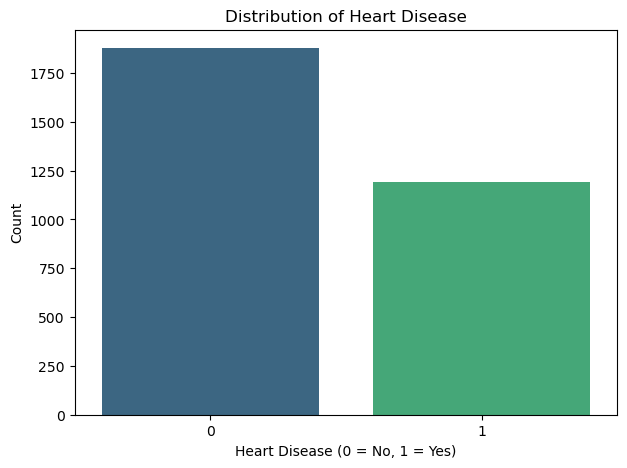

In [17]:
# 1. Distribution of Heart Disease (Target Variable)
plt.figure(figsize=(7, 5))
sns.countplot(x='heart_disease', data=df, palette='viridis')
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

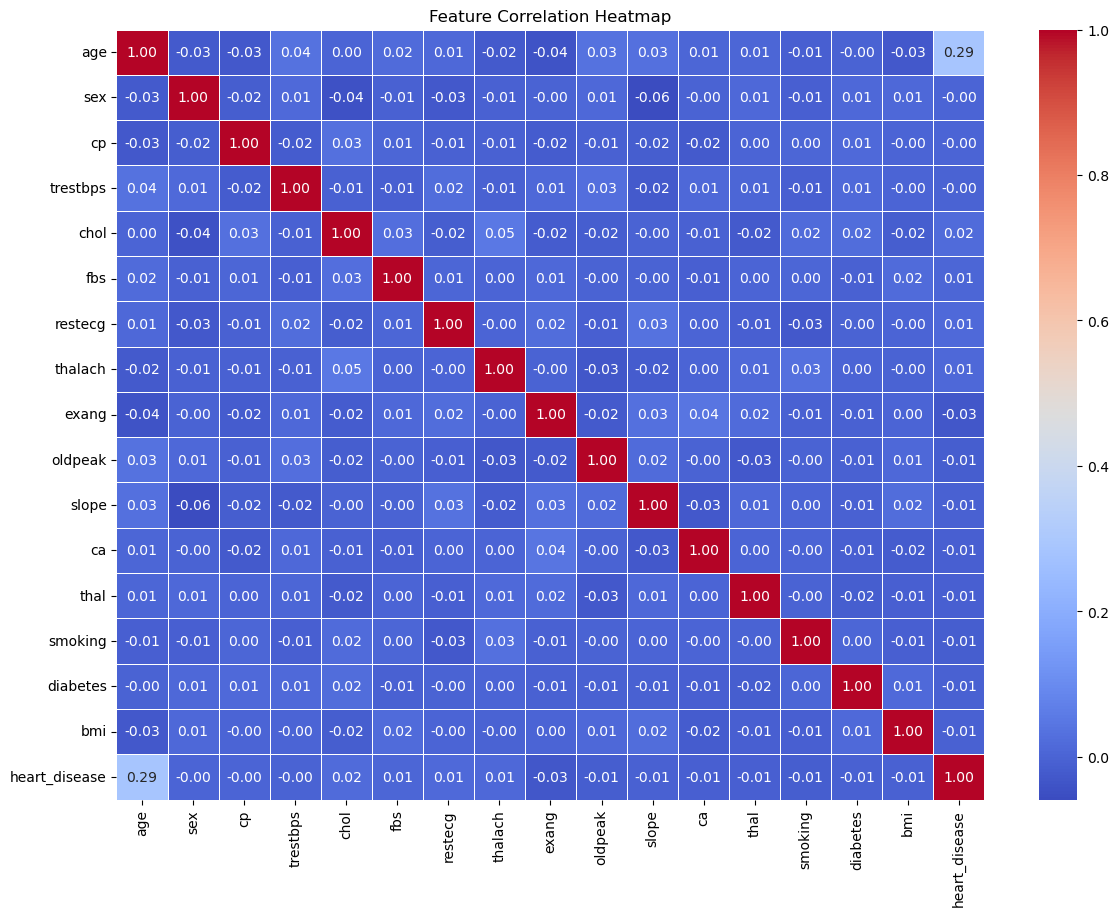

In [18]:
# 2. Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

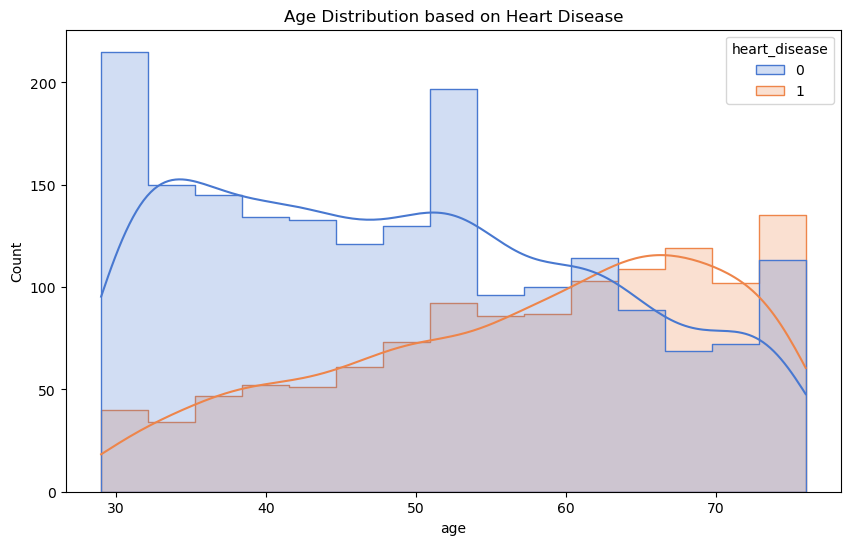

In [19]:
# 3. Age Distribution by Heart Disease Status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, element='step', palette='muted')
plt.title('Age Distribution based on Heart Disease')
plt.show()

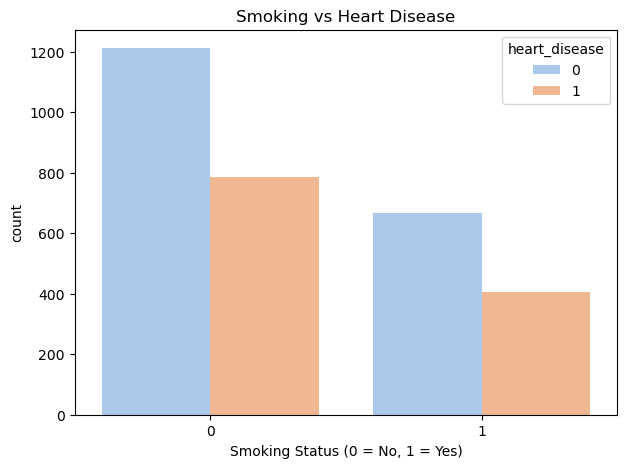

In [20]:
# 4. Impact of Smoking on Heart Disease
plt.figure(figsize=(7, 5))
sns.countplot(x='smoking', hue='heart_disease', data=df, palette='pastel')
plt.title('Smoking vs Heart Disease')
plt.xlabel('Smoking Status (0 = No, 1 = Yes)')
plt.show()

C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\3282289279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y='chol', data=df, palette='Set2')


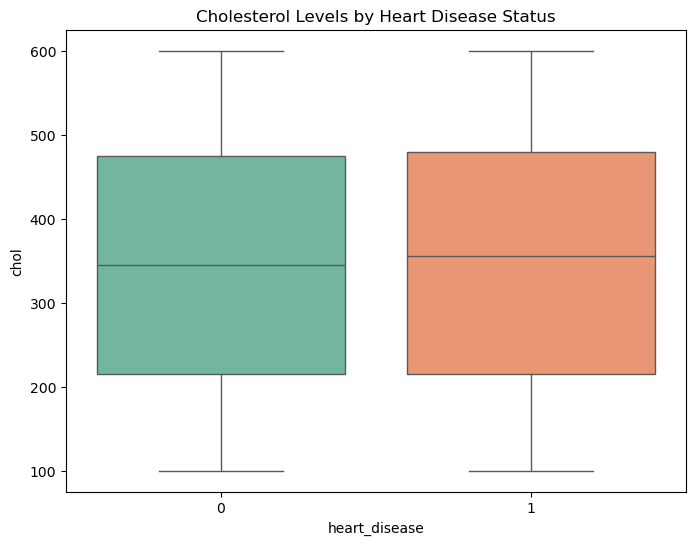

In [21]:
# 5. Cholesterol Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='heart_disease', y='chol', data=df, palette='Set2')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.show()

# Exploratory Data Analysis (EDA)

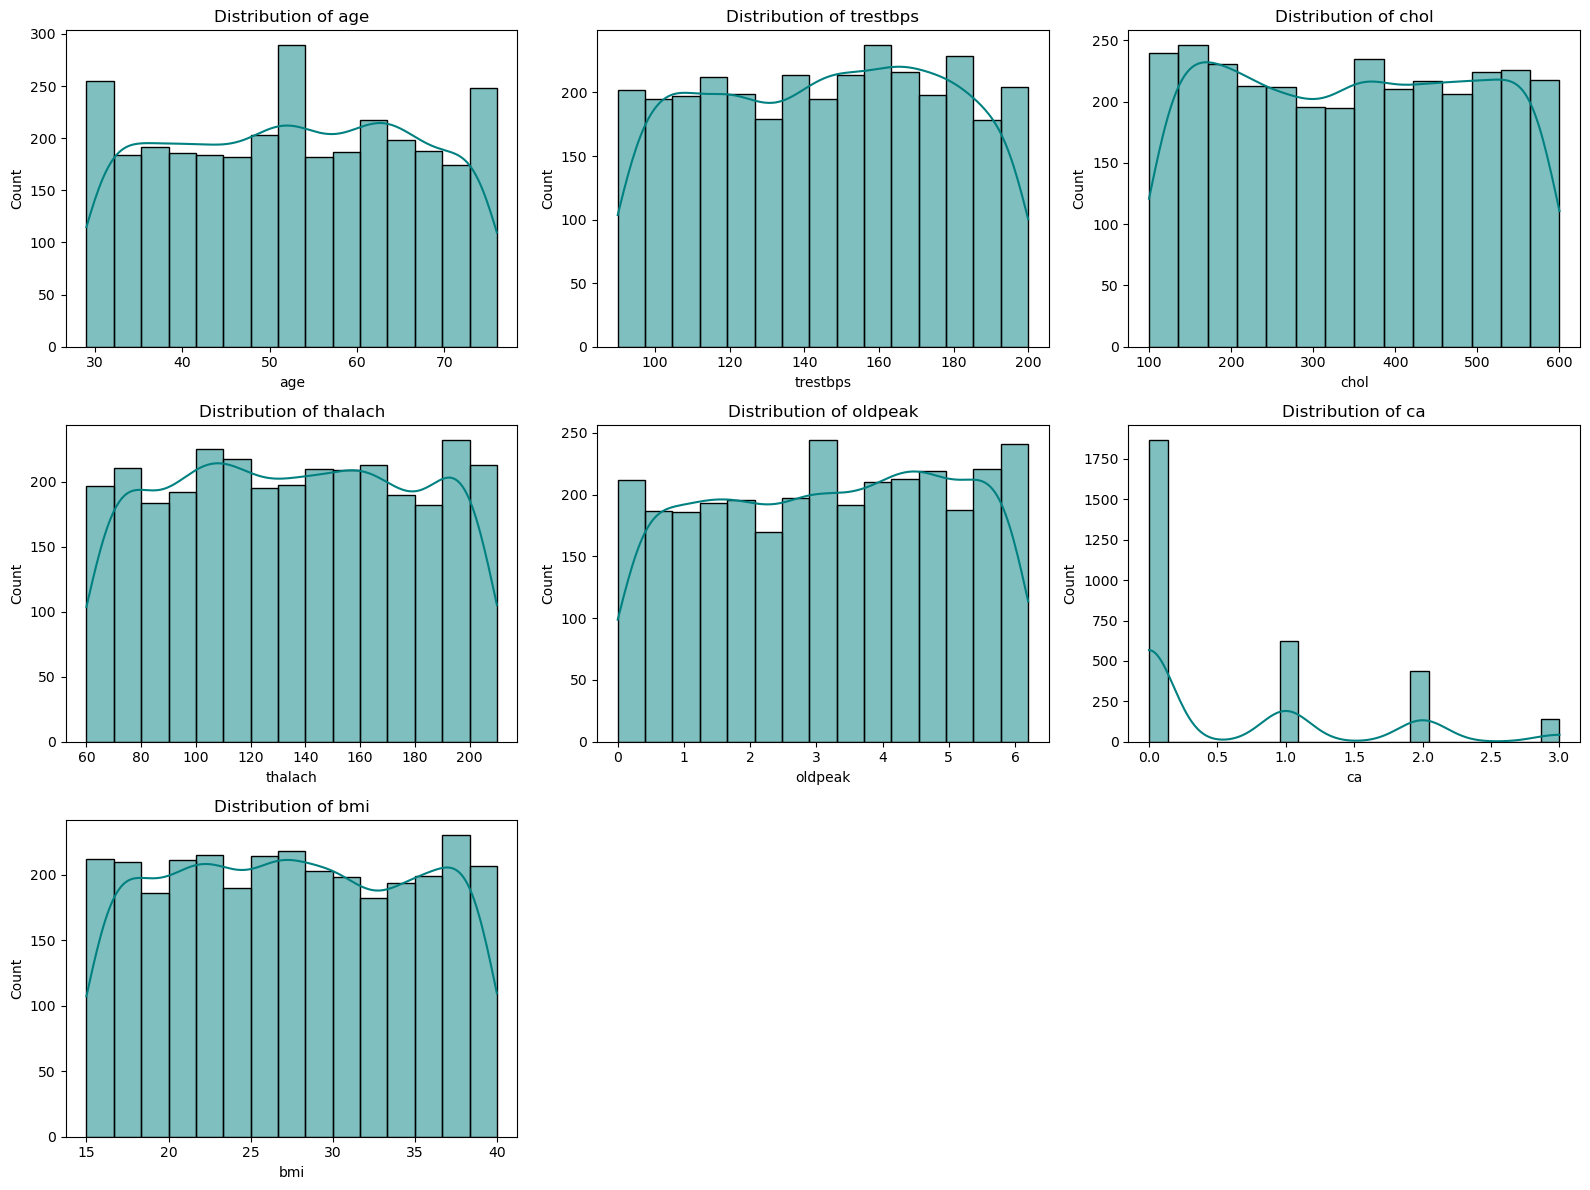

In [22]:
# 1. Numerical Distribution Plots
plt.figure(figsize=(16, 12))
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'bmi']
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\1730042321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\1730042321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\1730042321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\1730042321.py:6: FutureWarning: 

Passing `

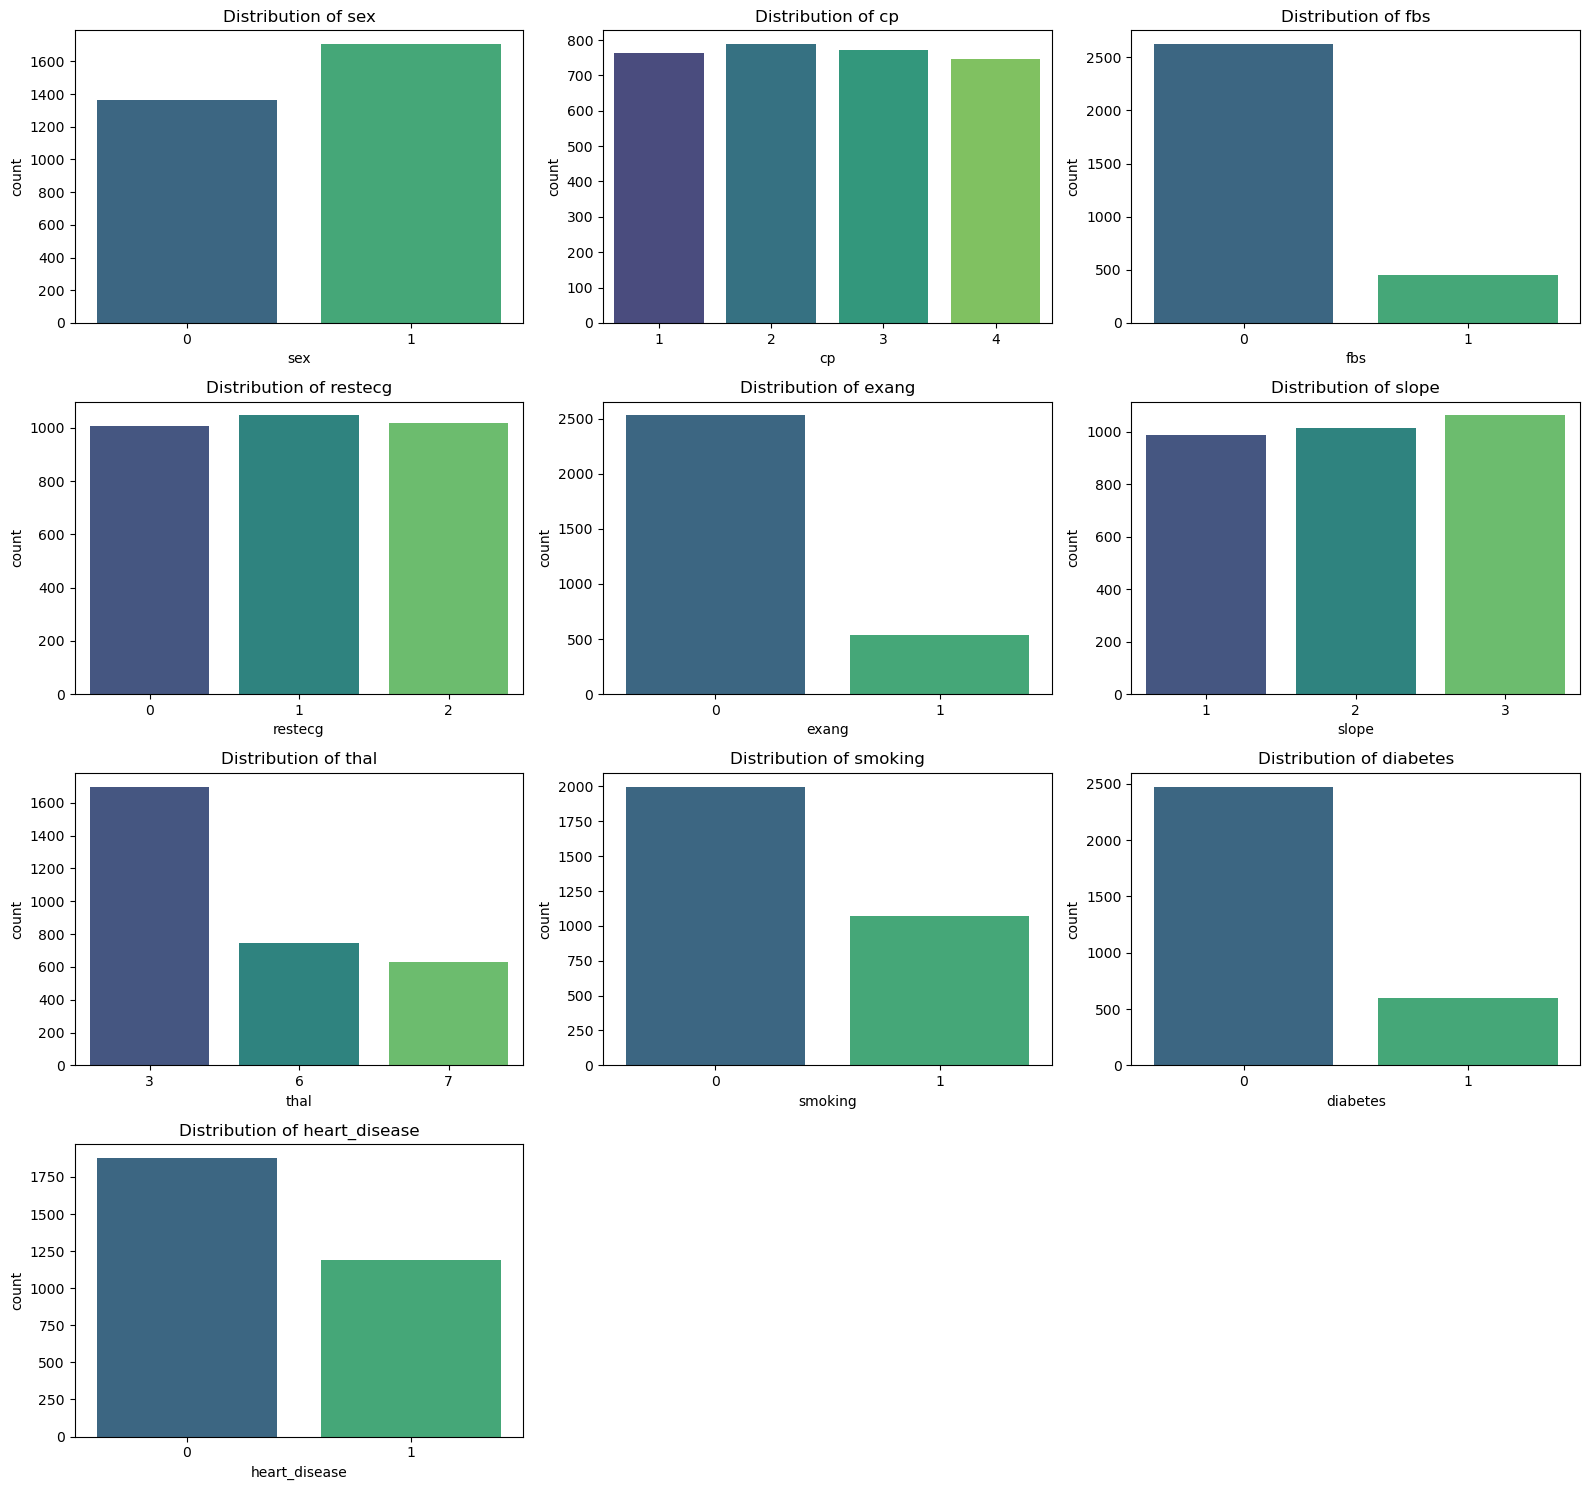

In [23]:
# 2. Categorical Distribution Plots
plt.figure(figsize=(16, 15))
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'smoking', 'diabetes', 'heart_disease']
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [24]:
# 3. Print Skewness and Kurtosis
print(df[num_cols].skew())

age        -0.020724
trestbps   -0.040295
chol        0.010539
thalach     0.001477
oldpeak    -0.067012
ca          1.192915
bmi         0.012683
dtype: float64


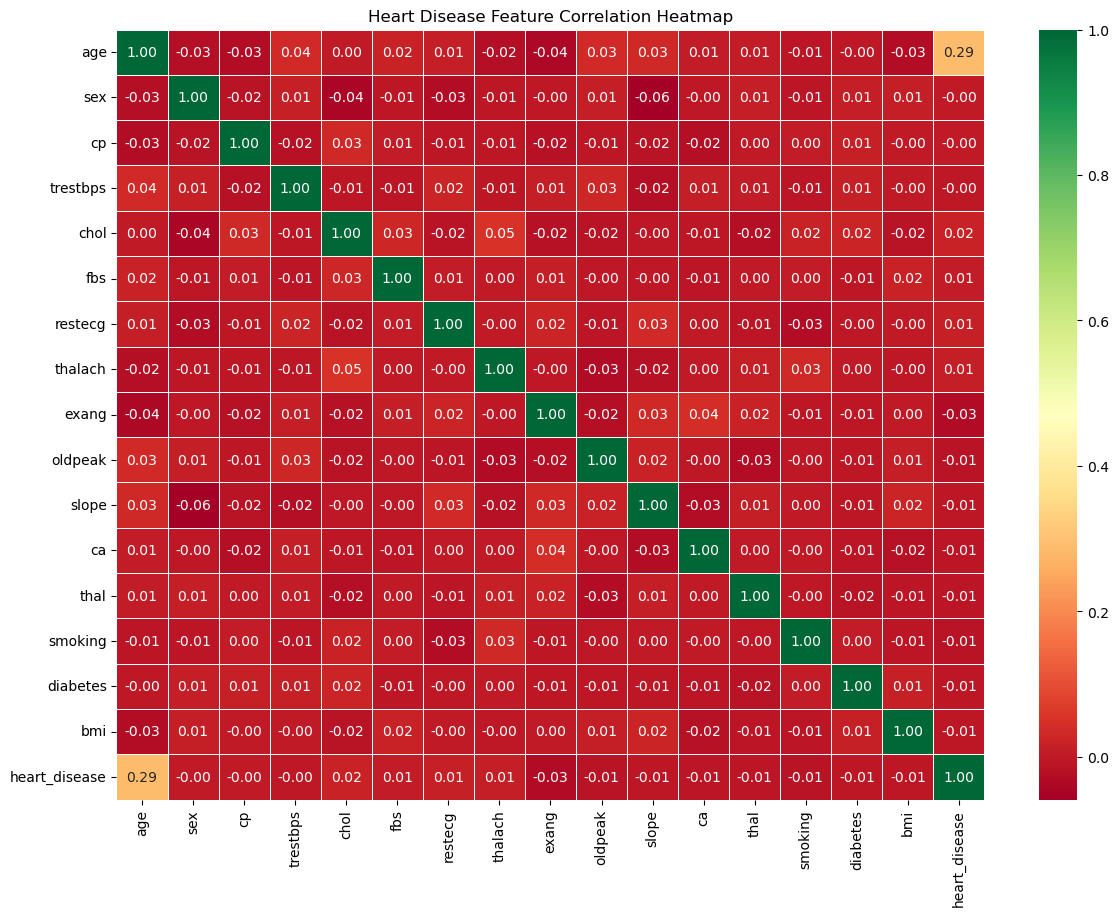

Correlation of all features with Heart Disease:
heart_disease    1.000000
age              0.286731
chol             0.015789
restecg          0.012317
thalach          0.007567
fbs              0.006693
cp              -0.000166
sex             -0.000897
trestbps        -0.002260
bmi             -0.005477
diabetes        -0.006603
slope           -0.009266
thal            -0.010874
ca              -0.012953
oldpeak         -0.014341
smoking         -0.014909
exang           -0.033249
Name: heart_disease, dtype: float64


In [26]:
# Calculating the correlation matrix
corr_matrix = df.corr()

# Creating a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Heart Disease Feature Correlation Heatmap')
plt.show()

# Specifically looking at correlation with the target
print("Correlation of all features with Heart Disease:")
print(corr_matrix['heart_disease'].sort_values(ascending=False))

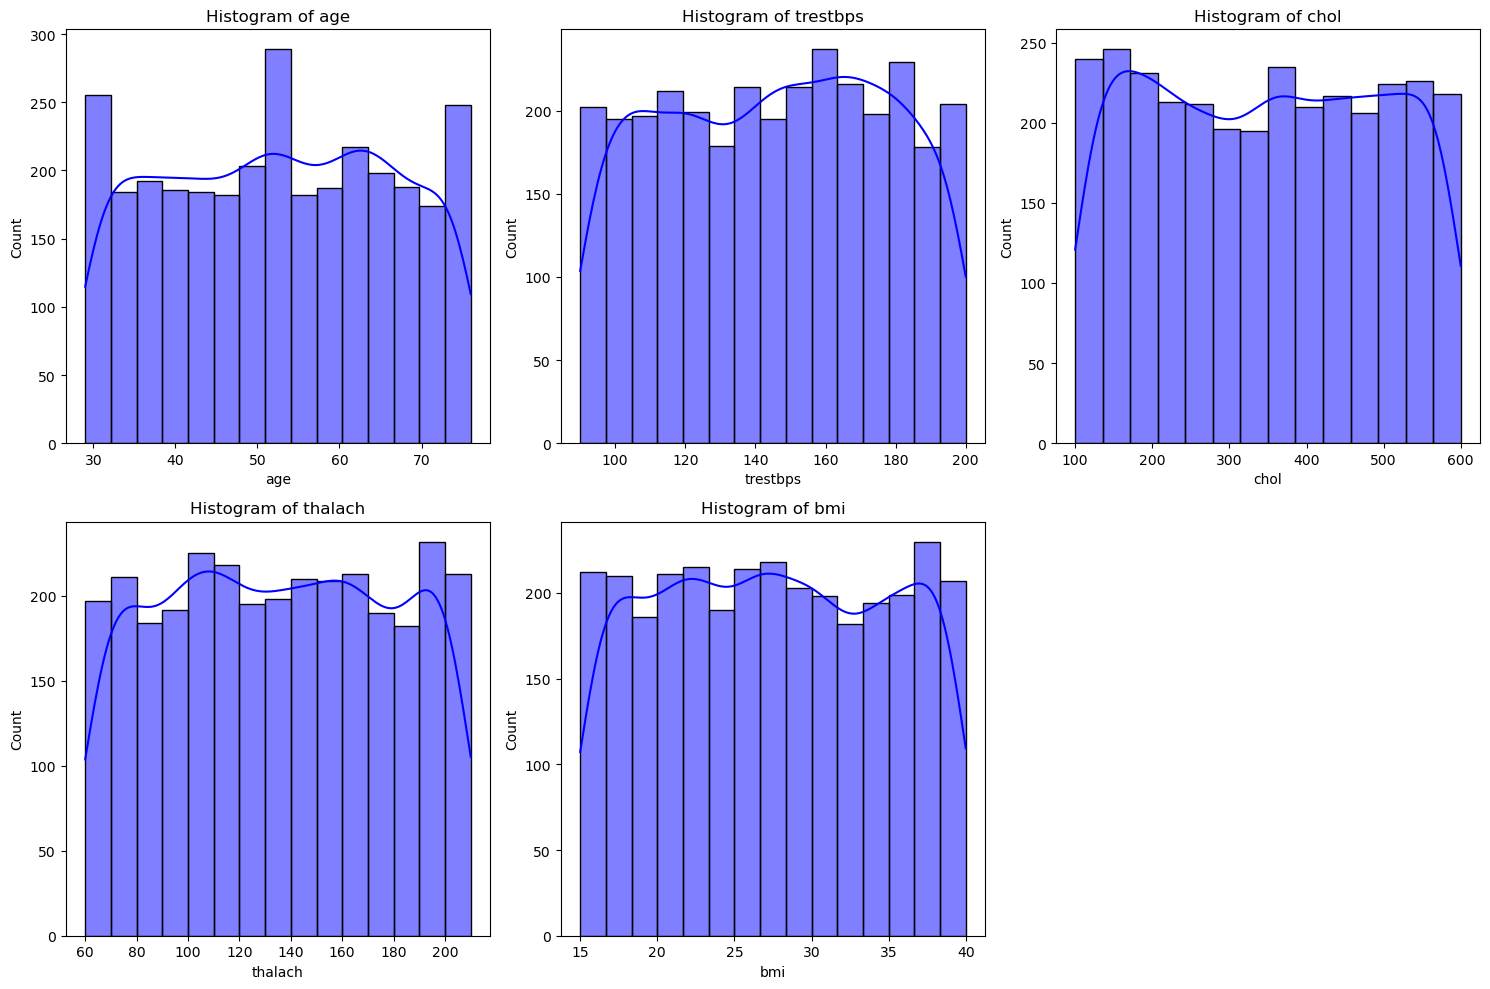

In [27]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'bmi']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\520043585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, palette='coolwarm')
C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\520043585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, palette='coolwarm')
C:\Users\unknown\AppData\Local\Temp\ipykernel_6776\520043585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y=col, data=df, palette='coolwarm')
C:\Users\unknown\AppData\Local\Temp\ipykern

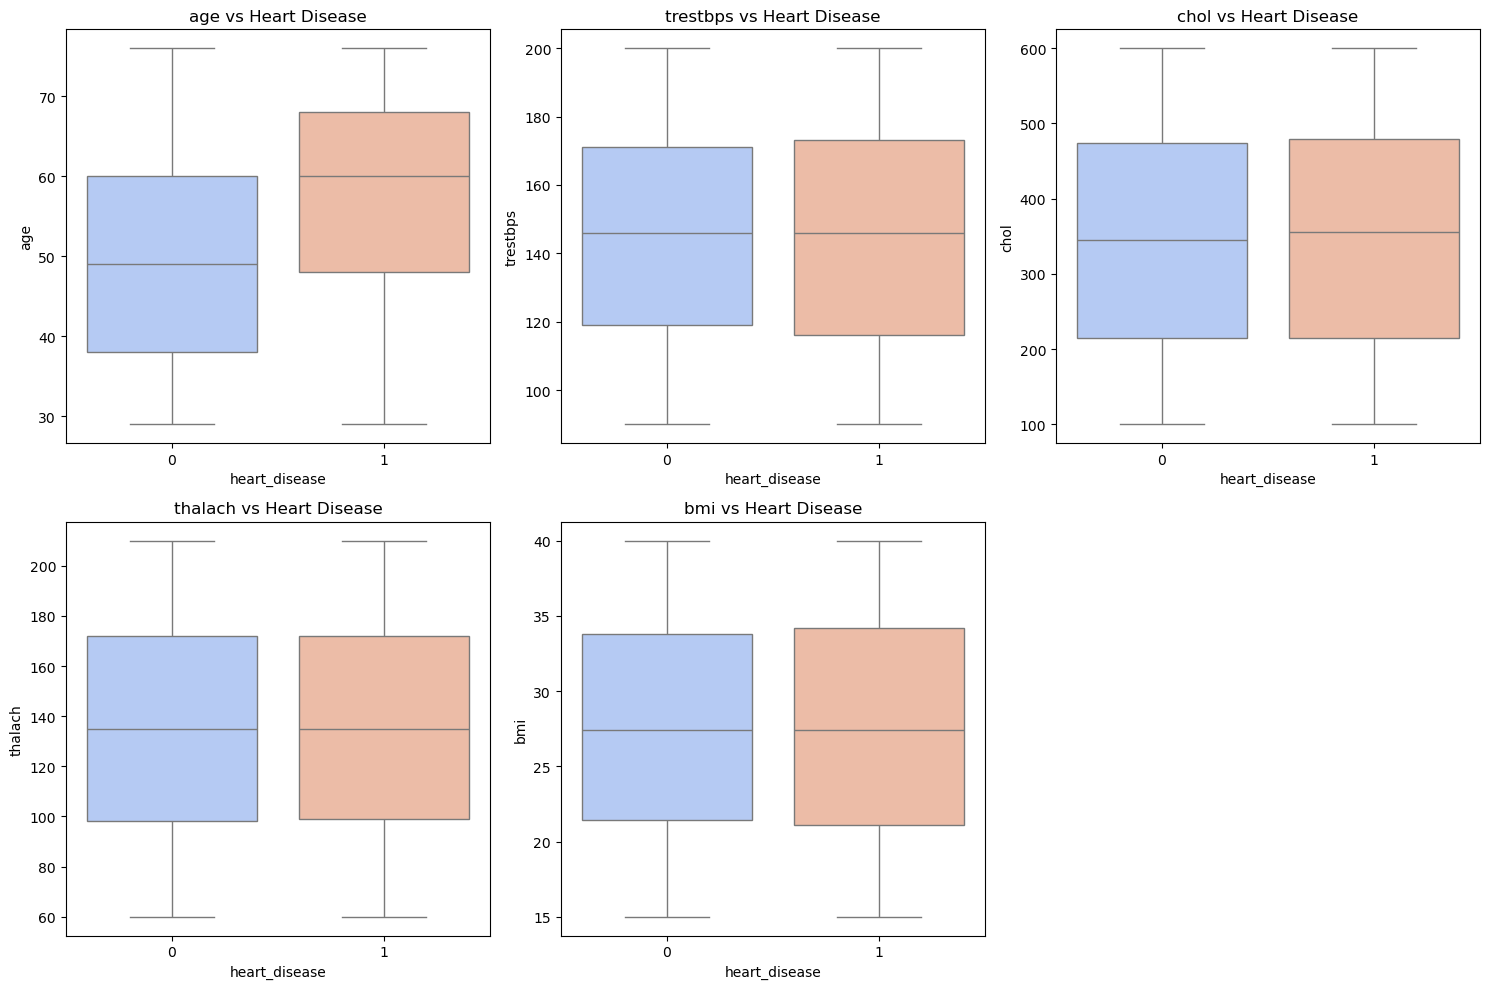

In [28]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='heart_disease', y=col, data=df, palette='coolwarm')
    plt.title(f'{col} vs Heart Disease')
plt.tight_layout()
plt.show()

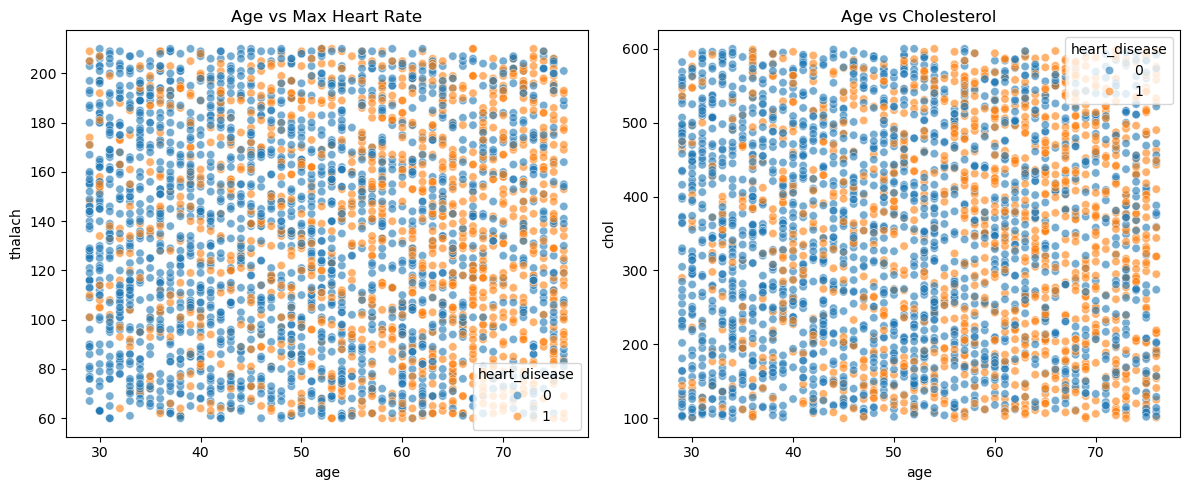

In [29]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='thalach', hue='heart_disease', data=df, alpha=0.6)
plt.title('Age vs Max Heart Rate')
plt.subplot(1, 2, 2)
sns.scatterplot(x='age', y='chol', hue='heart_disease', data=df, alpha=0.6)
# plt.title('Age vs Cholesterol')
plt.tight_layout()
plt.show()

In [ ]:
# Through Exploratory Data Analysis, we have identified that Age and Max Heart Rate are among the most influential 
# predictors.The data is clean, the target variable is balanced, and the numerical features follow distributions
# suitable for modeling. No single feature alone can predict the disease, suggesting that a multi-featureclassification
# approach is required.

# Feature Engineering

In [42]:
df['age_group'] = pd.cut(df['age'], bins=[0, 45, 60, 100], labels=['Young', 'Middle', 'Senior'])
df['metabolic_index'] = df['bmi'] * df['chol']


categorical_cols = ['cp', 'restecg', 'slope', 'thal', 'age_group']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_final.drop('heart_disease', axis=1)
y = df_final['heart_disease']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)


importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 5 Most Relevant Features:")
print(importances.head(5))

Top 5 Most Relevant Features:
age                0.129097
trestbps           0.100705
metabolic_index    0.100467
bmi                0.099817
chol               0.099372
dtype: float64


In [44]:
df['metabolic_index'] = df['bmi'] * df['chol']
df['age_group'] = pd.cut(df['age'], bins=[0, 45, 60, 100], labels=['Young', 'Middle', 'Senior'])

categorical_cols = ['cp', 'restecg', 'slope', 'thal', 'age_group']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'bmi', 'metabolic_index']
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

X = df_final.drop('heart_disease', axis=1)
y = df_final['heart_disease']
rf = RandomForestClassifier(random_state=42).fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Predictive Features:\n", importances.head(5))

df_final.to_csv('final_engineered_heart_data.csv', index=False)

Top Predictive Features:
 age                0.129097
trestbps           0.100705
metabolic_index    0.100467
bmi                0.099817
chol               0.099372
dtype: float64


#  Model Building

In [50]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print(f"Precision: {precision_score(y_test, y_pred):.2%}")
    print(f"Recall: {recall_score(y_test, y_pred):.2%}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.2f}\n")

--- Logistic Regression ---
Accuracy: 64.50%
Precision: 58.28%
Recall: 38.78%
F1-Score: 0.47

--- KNN ---
Accuracy: 58.96%
Precision: 48.07%
Recall: 35.51%
F1-Score: 0.41

--- Decision Tree ---
Accuracy: 64.01%
Precision: 57.06%
Recall: 39.59%
F1-Score: 0.47

--- Random Forest ---
Accuracy: 63.03%
Precision: 56.16%
Recall: 33.47%
F1-Score: 0.42



# Model Evaluation

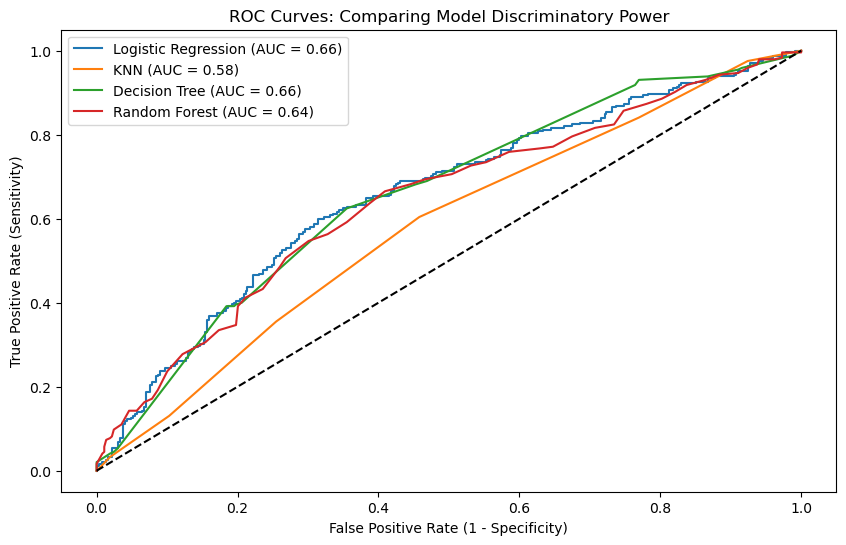

Logistic Regression CV Accuracy: 64.29% (+/- 2.09%)
KNN CV Accuracy: 60.90% (+/- 1.57%)
Decision Tree CV Accuracy: 63.24% (+/- 2.89%)
Random Forest CV Accuracy: 63.51% (+/- 2.02%)


In [53]:
plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Diagonal line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves: Comparing Model Discriminatory Power')
plt.legend()
plt.show()

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Accuracy: {scores.mean():.2%} (+/- {scores.std():.2%})")